# Phase 2 — Step 5: Visualisasi Sinyal + Wrap Up

Notebook penutup Phase 2.

Dua hal yang dilakukan di sini:
1. **Visualisasi sinyal** — plot BUY/SELL langsung di atas chart harga AAPL
   supaya bisa dilihat secara intuitif apakah timing model masuk akal
2. **Ringkasan Phase 2** — rekap semua yang sudah dibangun dari Step 2 sampai 4

## Bagian 1 — Setup & Rekonstruksi Data

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings, joblib, json, os
warnings.filterwarnings('ignore')

# Load model + metadata
model  = joblib.load('../../models/xgb_signal_model_v2.pkl')
scaler = joblib.load('../../models/signal_scaler_v2.pkl')
with open('../../models/signal_model_meta_v2.json') as f:
    meta = json.load(f)
ALL_FEATURES = meta['all_features']

# Load data + rebuild fitur
df = pd.read_pickle('../../data/processed/aapl_labeled.pkl')

LAG_FEATURES = ['RSI', 'MACD', 'MACD_Signal', 'Close', 'BB_Width']
for feat in LAG_FEATURES:
    for lag in [1, 3, 5]:
        df[f'{feat}_lag{lag}'] = df[feat].shift(lag)

df['Return_3d']       = df['Close'].pct_change(3)
df['Return_5d']       = df['Close'].pct_change(5)
df['RSI_Slope']       = df['RSI'] - df['RSI'].shift(3)
macd_above            = (df['MACD'] > df['MACD_Signal']).astype(int)
df['MACD_Cross']      = macd_above - macd_above.shift(1)
df['Volume_Momentum'] = df['Volume_Ratio'] - df['Volume_Ratio'].shift(3)
df = df.dropna()

# Generate prediksi di seluruh dataset (bukan cuma test set)
# supaya chart bisa menampilkan sinyal di semua periode
SPLIT_DATE = '2023-08-16'
df_test    = df[df.index >= SPLIT_DATE].copy()

X_test_sc = scaler.transform(df_test[ALL_FEATURES].values)
proba     = model.predict_proba(X_test_sc)
df_test['Pred_Signal'] = model.predict(X_test_sc)
df_test['Prob_BUY']    = proba[:, 2]
df_test['Prob_SELL']   = proba[:, 0]
df_test['Max_Prob']    = proba.max(axis=1)

print(f'Data siap: {len(df_test)} hari test set')
print(f'Periode  : {df_test.index[0].date()} s/d {df_test.index[-1].date()}')
print(f'BUY sinyal : {(df_test.Pred_Signal==2).sum()} hari')
print(f'SELL sinyal: {(df_test.Pred_Signal==0).sum()} hari')

Data siap: 341 hari test set
Periode  : 2023-08-16 s/d 2024-12-20
BUY sinyal : 32 hari
SELL sinyal: 221 hari


## Bagian 2 — Chart Utama: Harga + Sinyal BUY/SELL

Ini visualisasi paling penting dari seluruh Phase 2.

Kita plot tiga panel:
- **Panel atas** — harga AAPL + titik BUY (hijau) dan SELL (merah)
- **Panel tengah** — RSI sebagai konteks momentum
- **Panel bawah** — confidence model per hari

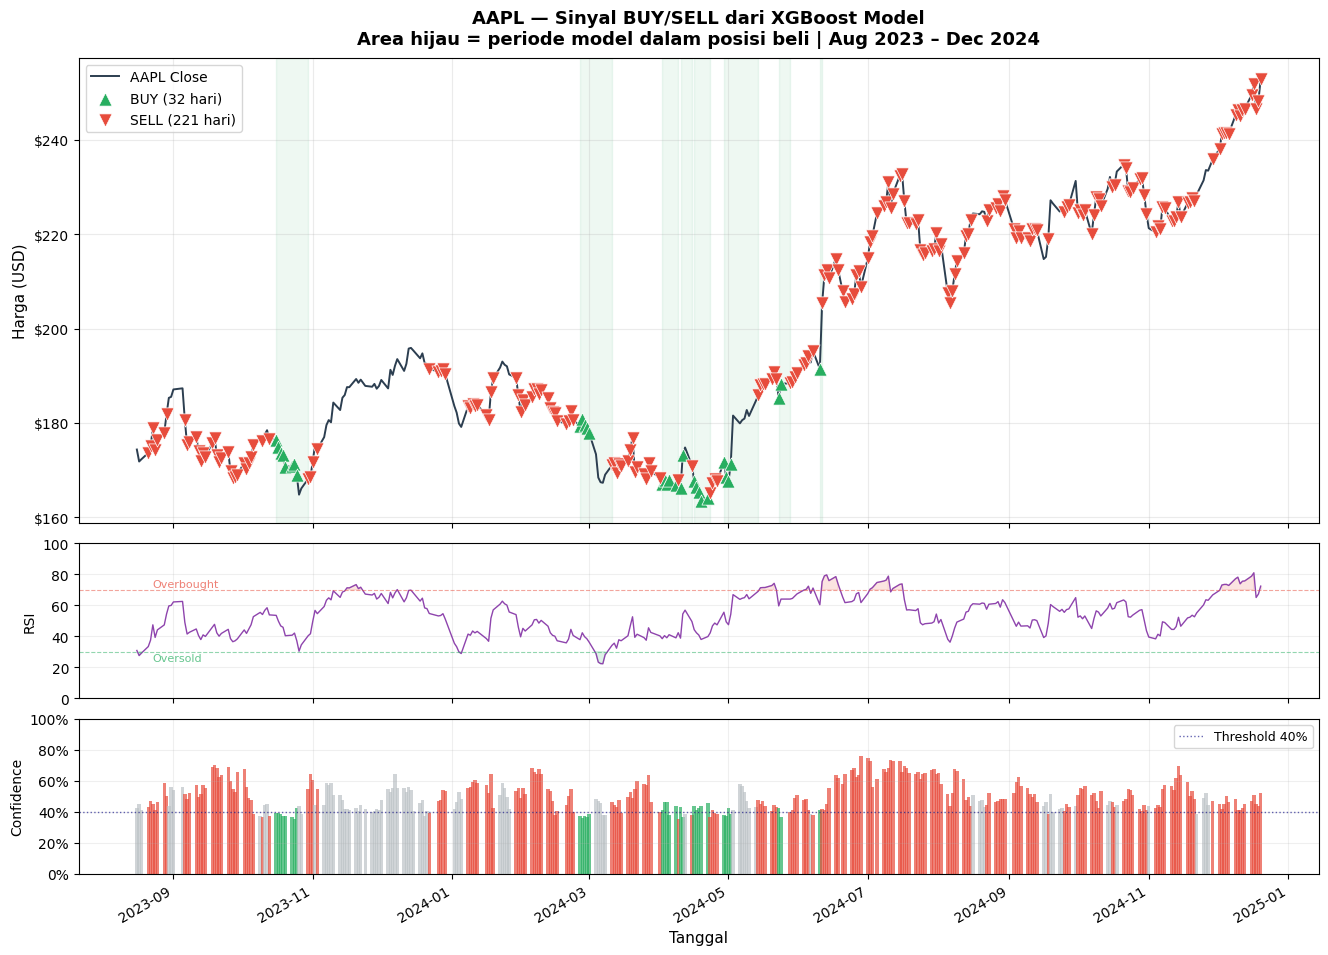

Chart utama disimpan.


In [7]:
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 1, height_ratios=[3, 1, 1], hspace=0.08)

ax1 = fig.add_subplot(gs[0])  # harga + sinyal
ax2 = fig.add_subplot(gs[1], sharex=ax1)  # RSI
ax3 = fig.add_subplot(gs[2], sharex=ax1)  # confidence

# --- Panel 1: Harga + Sinyal ---
ax1.plot(df_test.index, df_test['Close'],
         color='#2c3e50', linewidth=1.4, label='AAPL Close', zorder=2)

# Arsir area saat posisi aktif (antara BUY dan SELL berikutnya)
in_pos     = False
entry_date = None
for date, row in df_test.iterrows():
    sig = int(row['Pred_Signal'])
    if sig == 2 and not in_pos:
        in_pos     = True
        entry_date = date
    elif sig == 0 and in_pos:
        ax1.axvspan(entry_date, date, alpha=0.08, color='#27ae60', zorder=1)
        in_pos = False

# Titik BUY dan SELL
buy_days  = df_test[df_test['Pred_Signal'] == 2]
sell_days = df_test[df_test['Pred_Signal'] == 0]

ax1.scatter(buy_days.index, buy_days['Close'],
            color='#27ae60', marker='^', s=90, zorder=5,
            label=f'BUY ({len(buy_days)} hari)', edgecolors='white', linewidths=0.5)
ax1.scatter(sell_days.index, sell_days['Close'],
            color='#e74c3c', marker='v', s=90, zorder=5,
            label=f'SELL ({len(sell_days)} hari)', edgecolors='white', linewidths=0.5)

# Annotasi trade yang profitable besar
# Trade 6 (best): buy sekitar Apr 28, sell May 14 +7.96%
# Trade 8: sell Jun 11 +7.05%
ax1.set_title('AAPL — Sinyal BUY/SELL dari XGBoost Model\n'
              'Area hijau = periode model dalam posisi beli | '
              'Aug 2023 – Dec 2024',
              fontsize=13, fontweight='bold', pad=10)
ax1.set_ylabel('Harga (USD)', fontsize=11)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(alpha=0.25)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}'))
plt.setp(ax1.get_xticklabels(), visible=False)

# --- Panel 2: RSI ---
ax2.plot(df_test.index, df_test['RSI'],
         color='#8e44ad', linewidth=1, label='RSI (14)')
ax2.axhline(70, color='#e74c3c', linestyle='--', alpha=0.5, linewidth=0.8)
ax2.axhline(30, color='#27ae60', linestyle='--', alpha=0.5, linewidth=0.8)
ax2.fill_between(df_test.index, df_test['RSI'], 70,
                 where=df_test['RSI'] >= 70, alpha=0.15, color='#e74c3c')
ax2.fill_between(df_test.index, df_test['RSI'], 30,
                 where=df_test['RSI'] <= 30, alpha=0.15, color='#27ae60')
ax2.set_ylabel('RSI', fontsize=10)
ax2.set_ylim(0, 100)
ax2.text(df_test.index[5], 72, 'Overbought', fontsize=8, color='#e74c3c', alpha=0.7)
ax2.text(df_test.index[5], 24, 'Oversold',   fontsize=8, color='#27ae60', alpha=0.7)
ax2.grid(alpha=0.2)
plt.setp(ax2.get_xticklabels(), visible=False)

# --- Panel 3: Confidence ---
colors_conf = ['#e74c3c' if s == 0 else '#27ae60' if s == 2 else '#bdc3c7'
               for s in df_test['Pred_Signal']]
ax3.bar(df_test.index, df_test['Max_Prob'],
        color=colors_conf, alpha=0.7, width=1.5)
ax3.axhline(0.40, color='navy', linestyle=':', linewidth=1,
            label='Threshold 40%', alpha=0.6)
ax3.set_ylabel('Confidence', fontsize=10)
ax3.set_ylim(0, 1)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax3.legend(fontsize=9, loc='upper right')
ax3.grid(alpha=0.2)
ax3.set_xlabel('Tanggal', fontsize=11)

# Sync x-axis
fig.autofmt_xdate(rotation=30)

os.makedirs('../../reports', exist_ok=True)
plt.savefig('../../reports/phase2_step5_main_chart.png', dpi=140, bbox_inches='tight')
plt.show()
print('Chart utama disimpan.')

## Bagian 3 — Zoom: Periode Paling Aktif (Apr–Jun 2024)

Dari trade log Step 4, 5 dari 8 trade terjadi di periode April–Juni 2024.
Kita zoom in ke situ untuk lihat detail timing sinyal.

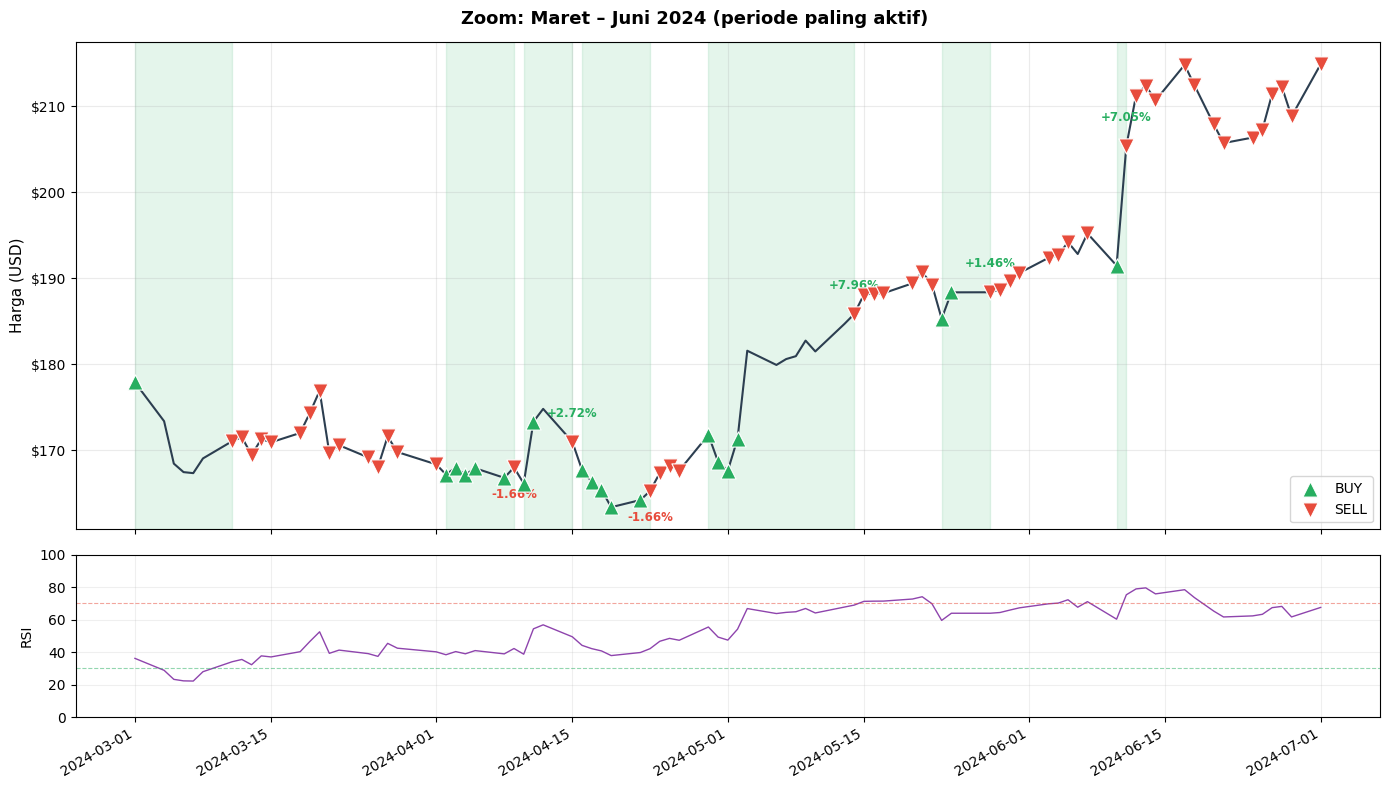

Zoom chart disimpan.


In [8]:
# Zoom ke periode paling aktif
zoom_start = '2024-03-01'
zoom_end   = '2024-07-01'
df_zoom    = df_test[(df_test.index >= zoom_start) & (df_test.index <= zoom_end)]

fig, axes = plt.subplots(2, 1, figsize=(14, 8),
                          gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
fig.suptitle('Zoom: Maret – Juni 2024 (periode paling aktif)',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(df_zoom.index, df_zoom['Close'],
        color='#2c3e50', linewidth=1.5, zorder=2)

# Arsir area posisi aktif
in_pos = False
entry_date = None
for date, row in df_zoom.iterrows():
    sig = int(row['Pred_Signal'])
    if sig == 2 and not in_pos:
        in_pos = True
        entry_date = date
    elif sig == 0 and in_pos:
        ax.axvspan(entry_date, date, alpha=0.12, color='#27ae60')
        in_pos = False

buy_z  = df_zoom[df_zoom['Pred_Signal'] == 2]
sell_z = df_zoom[df_zoom['Pred_Signal'] == 0]

ax.scatter(buy_z.index,  buy_z['Close'],
           color='#27ae60', marker='^', s=120, zorder=5,
           edgecolors='white', linewidths=0.8, label='BUY')
ax.scatter(sell_z.index, sell_z['Close'],
           color='#e74c3c', marker='v', s=120, zorder=5,
           edgecolors='white', linewidths=0.8, label='SELL')

# Annotasi P&L per trade di periode ini
trade_annot = [
    ('2024-04-09', 168.0, '-1.66%', 'red'),
    ('2024-04-15', 171.0, '+2.72%', 'green'),
    ('2024-04-23', 165.3, '-1.66%', 'red'),
    ('2024-05-14', 185.8, '+7.96%', 'green'),
    ('2024-05-28', 188.4, '+1.46%', 'green'),
    ('2024-06-11', 205.4, '+7.05%', 'green'),
]
for date_str, price, label, color in trade_annot:
    try:
        ax.annotate(label,
                    xy=(pd.Timestamp(date_str), price),
                    xytext=(0, 18 if color == 'green' else -22),
                    textcoords='offset points',
                    ha='center', fontsize=8.5, fontweight='bold',
                    color='#27ae60' if color == 'green' else '#e74c3c')
    except:
        pass

ax.set_ylabel('Harga (USD)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}'))

# Panel RSI zoom
axes[1].plot(df_zoom.index, df_zoom['RSI'], color='#8e44ad', linewidth=1)
axes[1].axhline(70, color='#e74c3c', linestyle='--', alpha=0.5, linewidth=0.8)
axes[1].axhline(30, color='#27ae60', linestyle='--', alpha=0.5, linewidth=0.8)
axes[1].set_ylabel('RSI', fontsize=10)
axes[1].set_ylim(0, 100)
axes[1].grid(alpha=0.2)

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.savefig('../../reports/phase2_step5_zoom_chart.png', dpi=140, bbox_inches='tight')
plt.show()
print('Zoom chart disimpan.')

## Bagian 4 — Ringkasan Phase 2 (Wrap Up)

Rekap lengkap semua yang sudah dibangun.

In [9]:
print('=' * 65)
print('           RINGKASAN PHASE 2 — BUY/SELL SIGNAL ENGINE')
print('=' * 65)

print('''
TUJUAN
  Membangun sistem yang bisa memprediksi kapan harus beli,
  jual, atau tahan saham AAPL — berdasarkan indikator teknikal.

APA YANG DIBANGUN
  Step 2 — Labeling
    Membuat label BUY/SELL/HOLD dari data historis
    menggunakan future return 5 hari dengan threshold 2%.
    Dataset: 1701 hari, distribusi SELL 22% / HOLD 42% / BUY 36%

  Step 3 — Model klasifikasi
    Melatih Random Forest dan XGBoost untuk memprediksi sinyal.
    Total fitur: 30 (10 base + 15 lag + 5 momentum)
    Best model: XGBoost dengan F1 macro 0.275

  Step 3b — Model improvement
    Tambah lag features (RSI/MACD 1,3,5 hari lalu) dan
    momentum features (RSI slope, MACD crossover, return 3d/5d).
    Hyperparameter tuning dengan RandomizedSearchCV.

  Step 4 — Backtesting
    Simulasi trading di test set (Aug 2023 - Dec 2024, 341 hari)
    dengan modal awal $10,000.

  Step 5 — Visualisasi (notebook ini)
    Plot sinyal di atas chart harga untuk sanity check visual.
''')

print('HASIL BACKTESTING')
print('-' * 65)
print(f'{"Strategi":<26} {"Return":>8} {"Sharpe":>8} {"Max DD":>9} {"Trades":>8}')
print('-' * 65)
results = [
    ('Buy & Hold (benchmark)', 44.9, 1.38, -16.6, 0),
    ('Signal — all',            7.5, 0.54, -11.4, 8),
    ('Signal — conf >= 40%',   19.4, 1.33,  -6.5, 5),
    ('Signal — conf >= 50%',    0.0, 0.00,   0.0, 0),
]
for name, ret, sharpe, dd, trades in results:
    print(f'{name:<26} {ret:>7.1f}%  {sharpe:>7.2f}  {dd:>8.1f}%  {trades:>7}')
print('-' * 65)

print('''
TEMUAN UTAMA
  1. Model tidak mengalahkan Buy & Hold di periode bull market
     (AAPL +44.9%). Ini normal untuk model teknikal.

  2. Strategi conf >= 40% punya Sharpe ratio 1.33 (vs B&H 1.38)
     dengan drawdown jauh lebih kecil (-6.5% vs -16.6%).
     Artinya model berguna sebagai risk management tool.

  3. Dari 8 trades: 5 win (62.5%), avg win $371 vs avg loss $368.
     Risk/Reward 1.01x — masih perlu improvement.

KETERBATASAN
  - Hanya pakai data teknikal, belum ada sentimen / news
  - Data training sampai 2022, belum retrain dengan data 2025-2026
  - Belum ada risk management (stop-loss, position sizing)
  - Backtesting pakai harga close — tidak memperhitungkan slippage

NEXT: PHASE 3
  - Update data 2025-2026 + retrain semua model
  - Tambah risk management (stop-loss, position sizing)
  - Backtest ulang dengan data yang lebih fresh
  - Opsional: tambah sentimen (Fear & Greed Index)
''')
print('=' * 65)
print('Phase 2 selesai.')

           RINGKASAN PHASE 2 — BUY/SELL SIGNAL ENGINE

TUJUAN
  Membangun sistem yang bisa memprediksi kapan harus beli,
  jual, atau tahan saham AAPL — berdasarkan indikator teknikal.

APA YANG DIBANGUN
  Step 2 — Labeling
    Membuat label BUY/SELL/HOLD dari data historis
    menggunakan future return 5 hari dengan threshold 2%.
    Dataset: 1701 hari, distribusi SELL 22% / HOLD 42% / BUY 36%

  Step 3 — Model klasifikasi
    Melatih Random Forest dan XGBoost untuk memprediksi sinyal.
    Total fitur: 30 (10 base + 15 lag + 5 momentum)
    Best model: XGBoost dengan F1 macro 0.275

  Step 3b — Model improvement
    Tambah lag features (RSI/MACD 1,3,5 hari lalu) dan
    momentum features (RSI slope, MACD crossover, return 3d/5d).
    Hyperparameter tuning dengan RandomizedSearchCV.

  Step 4 — Backtesting
    Simulasi trading di test set (Aug 2023 - Dec 2024, 341 hari)
    dengan modal awal $10,000.

  Step 5 — Visualisasi (notebook ini)
    Plot sinyal di atas chart harga untuk sanit

## Bagian 5 — Simpan Summary Chart untuk README

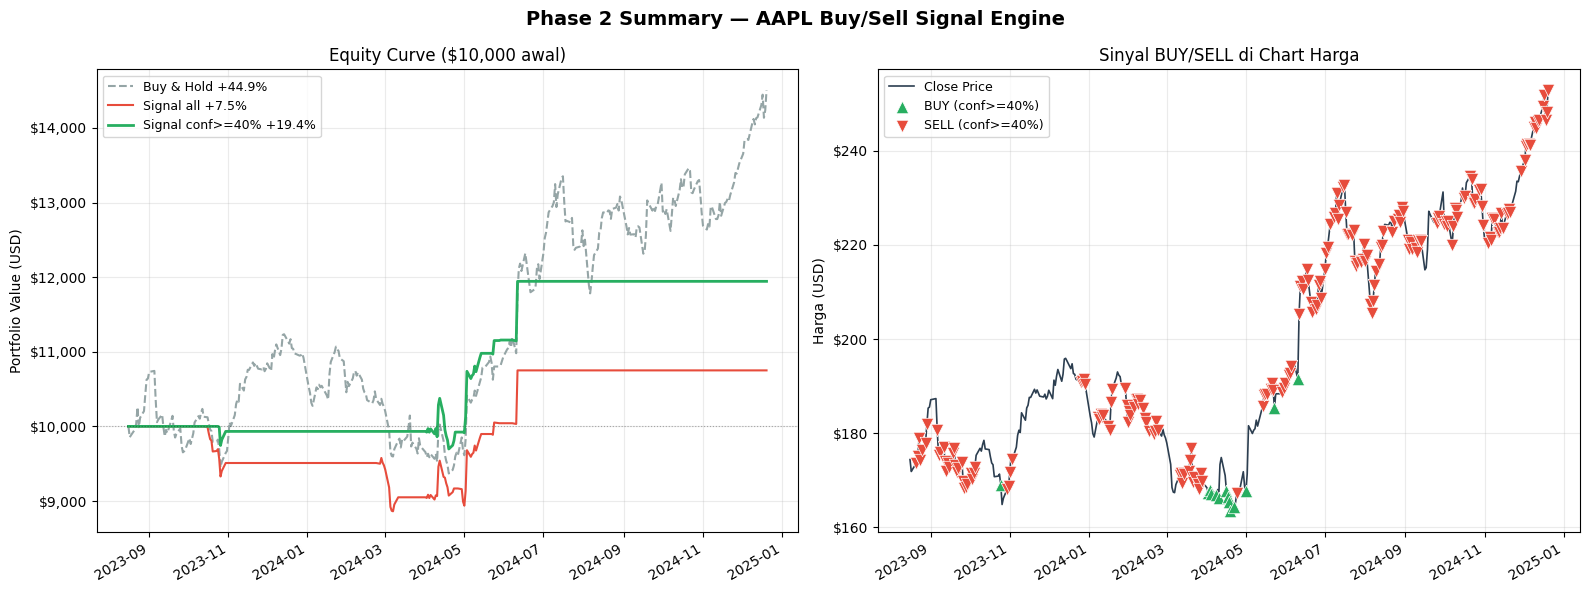

Summary chart disimpan ke ../../reports/phase2_summary.png
Siap dipakai di README GitHub!


In [10]:
# Bikin satu chart ringkasan yang bagus untuk README GitHub
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phase 2 Summary — AAPL Buy/Sell Signal Engine',
             fontsize=14, fontweight='bold')

# --- Plot kiri: Equity curve ---
ax = axes[0]

# Rekonstruksi equity curve sederhana
def simple_equity(df, conf_thresh=0.0, initial=10000, tc=0.001):
    cash, shares, in_pos = initial, 0.0, False
    equity = []
    for _, row in df.iterrows():
        price  = float(row['Close'])
        signal = int(row['Pred_Signal']) if row['Max_Prob'] >= conf_thresh else 1
        if signal == 2 and not in_pos:
            shares = cash * (1 - tc) / price
            cash   = 0
            in_pos = True
        elif signal == 0 and in_pos:
            cash   = shares * price * (1 - tc)
            shares = 0
            in_pos = False
        equity.append(cash + shares * price)
    return pd.Series(equity, index=df.index)

# Buy & Hold
bh_equity = 10000 * (df_test['Close'] / df_test['Close'].iloc[0])

eq_all    = simple_equity(df_test, conf_thresh=0.0)
eq_40     = simple_equity(df_test, conf_thresh=0.40)

ax.plot(df_test.index, bh_equity, color='#95a5a6', linewidth=1.5,
        linestyle='--', label='Buy & Hold +44.9%')
ax.plot(df_test.index, eq_all, color='#e74c3c', linewidth=1.5,
        label='Signal all +7.5%')
ax.plot(df_test.index, eq_40, color='#27ae60', linewidth=2,
        label='Signal conf>=40% +19.4%')

ax.axhline(10000, color='black', linestyle=':', alpha=0.3, linewidth=0.8)
ax.set_title('Equity Curve ($10,000 awal)', fontsize=12)
ax.set_ylabel('Portfolio Value (USD)')
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
fig.autofmt_xdate(rotation=30)

# --- Plot kanan: Sinyal di chart harga ---
ax2 = axes[1]
ax2.plot(df_test.index, df_test['Close'],
         color='#2c3e50', linewidth=1.2, label='Close Price')

# Hanya plot sinyal dengan conf >= 40% (lebih bersih)
high_conf = df_test[df_test['Max_Prob'] >= 0.40]
buy_hc    = high_conf[high_conf['Pred_Signal'] == 2]
sell_hc   = high_conf[high_conf['Pred_Signal'] == 0]

ax2.scatter(buy_hc.index,  buy_hc['Close'],
            color='#27ae60', marker='^', s=80, zorder=5,
            edgecolors='white', linewidths=0.5, label=f'BUY (conf>=40%)')
ax2.scatter(sell_hc.index, sell_hc['Close'],
            color='#e74c3c', marker='v', s=80, zorder=5,
            edgecolors='white', linewidths=0.5, label=f'SELL (conf>=40%)')

ax2.set_title('Sinyal BUY/SELL di Chart Harga', fontsize=12)
ax2.set_ylabel('Harga (USD)')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.25)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}'))
fig.autofmt_xdate(rotation=30)

plt.tight_layout()
plt.savefig('../../reports/phase2_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Summary chart disimpan ke ../../reports/phase2_summary.png')
print('Siap dipakai di README GitHub!')

---

## Phase 2 selesai!

### Yang sudah dibangun di Phase 2:

| Step | Notebook | Output |
|---|---|---|
| Step 2 | `phase2_step2_labeling.ipynb` | `aapl_labeled.pkl` |
| Step 3 | `phase2_step3_classification.ipynb` | Model baseline RF + XGB |
| Step 3b | `phase2_step3b_improved.ipynb` | `xgb_signal_model_v2.pkl` |
| Step 4 | `phase2_step4_backtesting.ipynb` | Equity curve, trade log |
| Step 5 | `phase2_step5_visualization.ipynb` | Chart sinyal, summary |

### Next — Phase 3:
1. Update data 2025-2026 + retrain semua model
2. Tambah risk management (stop-loss, position sizing)
3. Backtest ulang
4. Opsional: sentimen (Fear & Greed Index)